# Misspecified Copulas in Credit Risk Models

**Companion notebook to Post 5 of the credit risk modeling series.**

This notebook reproduces the central simulation experiment of
Hamerle and Rösch (2005), *Misspecified Copulas in Credit Risk Models:
How Good is Gaussian?*, *Journal of Risk* 8(1), pp. 41–58, and extends it
along three directions:

1. A finer grid in $(\rho_{\text{true}}, \nu_{\text{true}})$ to chart the
   bias surface of the Gaussian quasi-MLE estimator under a t-copula data
   generating process.
2. A side-by-side comparison of the loss distribution under three regimes:
   the true t-copula, the Gaussian copula with the biased quasi-MLE
   estimate, and the Gaussian copula with the true correlation.
3. A consistency map identifying the parameter region of the data
   generating process that is compatible with a given empirical estimate of
   $\hat{\rho}_G$.

The central message: when borrower defaults are generated by a t-copula
with finite degrees of freedom and one calibrates assuming a Gaussian
copula, the asset correlation estimator absorbs the missing tail dependence
through an upward bias. The biased estimator delivers a forecasted loss
distribution that is close to the true one despite the model
misspecification. This is the mechanical reason the Basel IRB framework
survives in practice, and it is the lens through which the empirical
results in subsequent posts should be read.

Earlier posts in the series:

- Post 1, *The Basel IRB Formula*.
- Post 2, *Monte Carlo Acceleration with IS and QMC*.
- Post 3, *VaR vs Expected Shortfall*.
- Post 4, *Copulas and Tail Dependence*.

Repository: `github.com/mauriliopatino/credit-risk-modeling`.


## 1. Setup

The notebook uses a single configuration block so that runtime can be
controlled from the top. Default settings match the publishable
standard with $M_{\text{REPLICATIONS}} = 1000$ replications per cell on
the H-R Table 1 grid, $M_{\text{FINE}} = 500$ on a densified grid for
the bias function, and $M_{\text{SURF}} = 300$ on a densified grid for
the consistency map. Total runtime under default settings is
approximately one hour and ten minutes on a single core. The bias
function loop is the longest (about thirty-three minutes), followed by
the consistency map (about twenty-two minutes) and the H-R Table 1
replication (about fifteen minutes).

For interactive editing of the prose, set `SMOKE_TEST = True` in the
configuration cell. This collapses every loop to a thin pass that
completes in under one minute and produces qualitatively coarse but
structurally complete output, suitable for verifying that the notebook
runs end-to-end without re-executing the heavy loops. The
`SMOKE_TEST = True` figures are not publishable; they exist for
iteration only.

Both the start time and the end time of the run are printed by the
notebook so that total runtime is recoverable from the saved output
even if the kernel session is closed afterward.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import roots_hermite
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

rng_global = np.random.default_rng(20260507)


In [2]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
SMOKE_TEST = False   # Toggle for fast iteration (M reduced, fewer grid points)

# Paper baseline: T=10 years, N=1000 obligors, M=1000 replications per cell
T_PERIODS = 10
N_OBLIGORS = 1000

# Replication counts. The published H-R Table 1 uses M=1000 replications per
# cell. The defaults below match this publishable standard. Expect ~70 minutes
# of total runtime on a single core; the figure that takes longest is the
# bias function (~33 minutes) followed by the consistency map (~22 minutes)
# and the Table 1 replication (~15 minutes). For interactive editing of the
# prose use SMOKE_TEST = True, which collapses the loops to a thin pass that
# completes in under a minute.
M_REPLICATIONS = 1000 if not SMOKE_TEST else 20

# Gauss-Hermite nodes for marginal log-likelihood under Gaussian copula.
# Fifty nodes are more than enough for the inner integral over the systematic
# factor, and the cost is negligible.
GH_DEG = 50

# Timestamp the start of the run so the total runtime is recoverable from
# the saved notebook output even if the kernel session is closed afterward.
import datetime
print(f"Run started: {datetime.datetime.now().isoformat(timespec='seconds')}")


Run started: 2026-05-21T18:02:51


## 2. Helper functions

The functions below implement three primitives:

- **Data simulation** under either Gaussian or one-factor t-copula. The
  one-factor t-copula is built by scaling a one-factor Gaussian latent
  vector by an independent $\sqrt{\nu / W}$ factor, where $W \sim \chi^2_\nu$.
- **Quasi-MLE estimation** of $(\lambda, \rho)$ under the Gaussian
  assumption. The estimator integrates out the systematic factor by
  Gauss-Hermite quadrature and maximizes the resulting marginal likelihood
  over the panel.
- **The conditional default rate** under each copula, used both for
  simulation and for computing the marginal likelihood of the default
  count vector.


In [3]:
# -----------------------------------------------------------------------------
# Conditional default rate functions
# -----------------------------------------------------------------------------

def gaussian_conditional_pd(z, lam, rho):
    """Conditional default rate under the one-factor Gaussian copula.

    Computes Phi((Phi^{-1}(lam) - sqrt(rho)*Z) / sqrt(1 - rho)).

    Parameters
    ----------
    z : float or ndarray
        Realisation of the systematic factor Z (standard normal).
    lam : float
        Marginal default probability, in (0, 1).
    rho : float
        Asset correlation, in (0, 1).

    Returns
    -------
    p : float or ndarray
        Conditional probability that an individual obligor defaults given Z.
    """
    threshold = stats.norm.ppf(lam)
    return stats.norm.cdf((threshold - np.sqrt(rho) * z) / np.sqrt(1.0 - rho))


def t_conditional_pd(z, w, lam, rho, nu):
    """Conditional default rate under the one-factor t-copula.

    Construction: latent variable T_i = (sqrt(rho)*Z + sqrt(1-rho)*eps_i)
    divided by sqrt(W/nu), with W ~ chi-squared(nu) and eps_i, Z standard
    normal. Default occurs when T_i is below the t-distribution quantile
    t_nu^{-1}(lam) so that the marginal default probability equals lam.

    Conditional on (Z, W), default of obligor i is equivalent to
    eps_i < (c_t * sqrt(W/nu) - sqrt(rho)*Z) / sqrt(1-rho).

    Parameters
    ----------
    z : float or ndarray
        Realisation of the systematic Gaussian factor.
    w : float or ndarray
        Realisation of the chi-squared factor with nu degrees of freedom.
    lam : float
        Marginal default probability.
    rho : float
        Asset correlation, in (0, 1).
    nu : float
        Degrees of freedom of the t-copula, nu > 2.

    Returns
    -------
    p : float or ndarray
        Conditional probability of default given (Z, W).
    """
    c_t = stats.t.ppf(lam, df=nu)
    return stats.norm.cdf(
        (c_t * np.sqrt(w / nu) - np.sqrt(rho) * z) / np.sqrt(1.0 - rho)
    )


In [4]:
# -----------------------------------------------------------------------------
# Data simulation
# -----------------------------------------------------------------------------

def simulate_gaussian(rho, lam, T, N, rng):
    """Simulate a default count time series under the one-factor Gaussian copula.

    For each period t = 1..T, the systematic factor Z_t is drawn from N(0,1)
    and the conditional default probability p_t is computed. The default
    count d_t is then a binomial draw with N trials and probability p_t.

    Parameters
    ----------
    rho : float
        True asset correlation.
    lam : float
        True marginal default probability.
    T : int
        Number of periods.
    N : int
        Number of obligors per period.
    rng : numpy.random.Generator
        Source of randomness.

    Returns
    -------
    defaults : ndarray of shape (T,)
        Realised default counts.
    """
    z = rng.standard_normal(T)
    p = gaussian_conditional_pd(z, lam, rho)
    return rng.binomial(N, p)


def simulate_t_copula(rho, nu, lam, T, N, rng):
    """Simulate a default count time series under the one-factor t-copula.

    Parameters
    ----------
    rho : float
        True asset correlation.
    nu : float
        True degrees of freedom of the t-copula. Use nu = np.inf to recover
        the Gaussian copula limit.
    lam : float
        True marginal default probability.
    T : int
        Number of periods.
    N : int
        Number of obligors per period.
    rng : numpy.random.Generator
        Source of randomness.

    Returns
    -------
    defaults : ndarray of shape (T,)
        Realised default counts.
    """
    if not np.isfinite(nu):
        return simulate_gaussian(rho, lam, T, N, rng)
    z = rng.standard_normal(T)
    w = rng.chisquare(df=nu, size=T)
    p = t_conditional_pd(z, w, lam, rho, nu)
    return rng.binomial(N, p)


In [5]:
# -----------------------------------------------------------------------------
# Gaussian quasi-MLE
# -----------------------------------------------------------------------------

# Pre-compute Gauss-Hermite nodes and log-weights once at import time.
from scipy.special import logsumexp
_GH_NODES, _GH_WEIGHTS = roots_hermite(GH_DEG)
_LOG_GH_WEIGHTS = np.log(_GH_WEIGHTS) - 0.5 * np.log(np.pi)


def total_loglik_gaussian(params, defaults, N):
    """Total log-likelihood of the panel under the Gaussian copula.

    The full panel log-likelihood is

        log L(lam, rho) = sum_t log integral Bin(d_t; N, p_G(z; lam, rho)) phi(z) dz,

    where p_G(z; lam, rho) = Phi((Phi^{-1}(lam) - sqrt(rho) z) / sqrt(1 - rho))
    is the conditional default rate given the systematic factor. Each period
    integral is evaluated by Gauss-Hermite quadrature with the standard
    change of variable Z = sqrt(2) x. Working in log space with logsumexp
    avoids the overflow that scipy.stats.binom.pmf is prone to when N is
    large and the conditional probability sits in the deep tails.

    The implementation broadcasts the binomial logpmf evaluation across all
    panel periods at once: the default vector and the conditional
    probability vector form a (T, GH_DEG) grid, and logsumexp collapses the
    quadrature axis. This vectorisation is the difference between a
    runtime of seconds and minutes for the replication grid.

    Parameters
    ----------
    params : tuple
        (lam, rho).
    defaults : array_like of shape (T,)
        Realised default counts.
    N : int
        Number of obligors per period.

    Returns
    -------
    log_lik : float
        Sum of per-period log-marginal-likelihoods.
    """
    lam, rho = params
    if not (0.0 < lam < 1.0 and 0.0 < rho < 1.0):
        return -1e10
    z_nodes = np.sqrt(2.0) * _GH_NODES
    p = gaussian_conditional_pd(z_nodes, lam, rho)
    p = np.clip(p, 1e-15, 1.0 - 1e-15)
    d_col = np.asarray(defaults).reshape(-1, 1)         # shape (T, 1)
    p_row = p.reshape(1, -1)                            # shape (1, GH_DEG)
    log_pmf = stats.binom.logpmf(d_col, N, p_row)       # shape (T, GH_DEG)
    log_lik_per_period = logsumexp(log_pmf + _LOG_GH_WEIGHTS, axis=1)
    return float(np.sum(log_lik_per_period))


def fit_gaussian_qml(defaults, N, init_grid=None):
    """Quasi-MLE estimation of (lam, rho) under the Gaussian copula.

    Uses Nelder-Mead with a small grid of starting points for rho. The
    log-likelihood as a function of rho is multimodal in some regions,
    particularly when the data are simulated from a heavy-tailed t-copula
    and the Gaussian model has to compensate with high rho_hat. A single
    starting point near rho = 0.10 will converge to a local optimum at
    moderate rho even when the global optimum lies near rho = 0.40 or
    higher. The multistart strategy below evaluates three starts spaced
    across the rho range and keeps the optimum with the highest log-
    likelihood.

    Parameters
    ----------
    defaults : ndarray of shape (T,)
        Realised default counts.
    N : int
        Number of obligors per period.
    init_grid : list of tuples, optional
        Starting points for (lam, rho).

    Returns
    -------
    lam_hat : float
    rho_hat : float
    log_lik : float
    converged : bool
    """
    if init_grid is None:
        init_grid = [(0.01, 0.05), (0.01, 0.20), (0.01, 0.45)]
    obj = lambda p: -total_loglik_gaussian(p, defaults, N)
    best_res = None
    for init in init_grid:
        res = minimize(
            obj, init, method="Nelder-Mead",
            options={"xatol": 1e-7, "fatol": 1e-7, "maxiter": 2000},
        )
        if best_res is None or res.fun < best_res.fun:
            best_res = res
    return (float(best_res.x[0]), float(best_res.x[1]),
            float(-best_res.fun), bool(best_res.success))


## 3. Replication of Hamerle-Rösch (2005), Table 1

The original table reports the average $\hat{\lambda}$ and $\hat{\rho}_G$
across one thousand replicated default time series, for the cross-product
of two marginal default probabilities, three values of $\rho_{\text{true}}$,
and three values of $\nu_{\text{true}}$. Each replication generates a
ten-period panel with one thousand obligors and estimates $(\lambda, \rho)$
under the Gaussian assumption.

The exercise has two purposes here. First, it is a sanity check that the
implementation matches the published results. Second, it produces the raw
material for the bias plot in the next section.


In [6]:
# -----------------------------------------------------------------------------
# Replication grid
# -----------------------------------------------------------------------------

if SMOKE_TEST:
    LAMBDA_GRID = [0.01]
    NU_GRID = [10.0]
    RHO_GRID = [0.0, 0.10]
else:
    LAMBDA_GRID = [0.01, 0.002]
    NU_GRID = [5.0, 10.0, 30.0]
    RHO_GRID = [0.0, 0.02, 0.10]

print(f"Replications per cell: M = {M_REPLICATIONS}")
print(f"Grid size: {len(LAMBDA_GRID)} x {len(NU_GRID)} x {len(RHO_GRID)} "
      f"= {len(LAMBDA_GRID) * len(NU_GRID) * len(RHO_GRID)} cells")


Replications per cell: M = 1000
Grid size: 2 x 3 x 3 = 18 cells


In [7]:
# -----------------------------------------------------------------------------
# Replication loop
# -----------------------------------------------------------------------------

def run_replication_cell(rho_true, nu_true, lam_true, M, T, N, seed):
    """Estimate Gaussian QML statistics on M simulated panels.

    For each of M replications, simulate a default panel under the
    one-factor t-copula with the given parameters, then fit the misspecified
    Gaussian model. Aggregate the M estimates into the average and standard
    deviation of (lam_hat, rho_hat).

    Returns a dictionary with the cell parameters and aggregated statistics.
    """
    rng = np.random.default_rng(seed)
    lam_hats = np.empty(M)
    rho_hats = np.empty(M)
    for m in range(M):
        d = simulate_t_copula(rho_true, nu_true, lam_true, T, N, rng)
        lam_hat, rho_hat, _, ok = fit_gaussian_qml(d, N)
        lam_hats[m] = lam_hat if ok else np.nan
        rho_hats[m] = rho_hat if ok else np.nan
    valid = ~np.isnan(rho_hats)
    return {
        "lam_true": lam_true,
        "nu_true": nu_true,
        "rho_true": rho_true,
        "lam_hat_mean": float(np.nanmean(lam_hats)),
        "lam_hat_sd": float(np.nanstd(lam_hats, ddof=1)),
        "rho_hat_mean": float(np.nanmean(rho_hats)),
        "rho_hat_sd": float(np.nanstd(rho_hats, ddof=1)),
        "n_valid": int(valid.sum()),
    }


cells_to_run = []
seed_counter = 1000
for lam in LAMBDA_GRID:
    for nu in NU_GRID:
        for rho in RHO_GRID:
            cells_to_run.append((rho, nu, lam, seed_counter))
            seed_counter += 1

results_table1 = []
for i, (rho, nu, lam, seed) in enumerate(cells_to_run, 1):
    out = run_replication_cell(rho, nu, lam, M_REPLICATIONS,
                               T_PERIODS, N_OBLIGORS, seed)
    results_table1.append(out)
    print(f"  [{i:2d}/{len(cells_to_run):2d}] lam={lam:.3f}  nu={nu:4.1f}  "
          f"rho_true={rho:.2f}  ->  rho_hat={out['rho_hat_mean']:.4f}  "
          f"(sd={out['rho_hat_sd']:.4f})")


  [ 1/18] lam=0.010  nu= 5.0  rho_true=0.00  ->  rho_hat=0.4228  (sd=0.1624)
  [ 2/18] lam=0.010  nu= 5.0  rho_true=0.02  ->  rho_hat=0.4381  (sd=0.1617)
  [ 3/18] lam=0.010  nu= 5.0  rho_true=0.10  ->  rho_hat=0.4446  (sd=0.1754)
  [ 4/18] lam=0.010  nu=10.0  rho_true=0.00  ->  rho_hat=0.2589  (sd=0.1307)
  [ 5/18] lam=0.010  nu=10.0  rho_true=0.02  ->  rho_hat=0.2688  (sd=0.1229)
  [ 6/18] lam=0.010  nu=10.0  rho_true=0.10  ->  rho_hat=0.3143  (sd=0.1452)
  [ 7/18] lam=0.010  nu=30.0  rho_true=0.00  ->  rho_hat=0.0810  (sd=0.0480)
  [ 8/18] lam=0.010  nu=30.0  rho_true=0.02  ->  rho_hat=0.0998  (sd=0.0605)
  [ 9/18] lam=0.010  nu=30.0  rho_true=0.10  ->  rho_hat=0.1743  (sd=0.0991)
  [10/18] lam=0.002  nu= 5.0  rho_true=0.00  ->  rho_hat=0.3618  (sd=0.3079)
  [11/18] lam=0.002  nu= 5.0  rho_true=0.02  ->  rho_hat=0.3226  (sd=0.3003)
  [12/18] lam=0.002  nu= 5.0  rho_true=0.10  ->  rho_hat=0.3188  (sd=0.3052)
  [13/18] lam=0.002  nu=10.0  rho_true=0.00  ->  rho_hat=0.3460  (sd=0.2590)

In [8]:
# -----------------------------------------------------------------------------
# Format as table mirroring the published H-R Table 1
# -----------------------------------------------------------------------------

df_t1 = pd.DataFrame(results_table1)
df_t1 = df_t1.sort_values(["lam_true", "nu_true", "rho_true"]).reset_index(drop=True)
df_display = df_t1[["lam_true", "nu_true", "rho_true",
                    "lam_hat_mean", "lam_hat_sd",
                    "rho_hat_mean", "rho_hat_sd"]].copy()
df_display.columns = ["lam_true", "nu_true", "rho_true",
                      "lam_hat", "SD(lam_hat)",
                      "rho_hat", "SD(rho_hat)"]
df_display = df_display.round(5)
df_display


,lam_true,nu_true,rho_true,lam_hat,SD(lam_hat),rho_hat,SD(rho_hat)
0,0.002,5.0,0.00,0.00618,0.01027,0.36182,0.30790
1,0.002,5.0,0.02,0.00487,0.00906,0.32257,0.30030
2,0.002,5.0,0.10,0.00511,0.00965,0.31878,0.30517
3,0.002,10.0,0.00,0.00581,0.00830,0.34601,0.25903
4,0.002,10.0,0.02,0.00539,0.00790,0.34692,0.25173
5,0.002,10.0,0.10,0.00581,0.00867,0.34414,0.27095
6,0.002,30.0,0.00,0.00236,0.00217,0.12214,0.11792
7,0.002,30.0,0.02,0.00268,0.00325,0.14861,0.13604
8,0.002,30.0,0.10,0.00351,0.00544,0.22103,0.19085
9,0.010,5.0,0.00,0.01026,0.00636,0.42284,0.16239


## 4. Bias surface of the Gaussian QML estimator

The replication grid above is sparse. To trace how the bias evolves as the
data generating process moves between Gaussian and heavy-tailed, the next
block sweeps a finer grid of $\nu_{\text{true}}$ at three values of
$\rho_{\text{true}}$ and plots the average $\hat{\rho}_G$ against
$\nu_{\text{true}}$. The horizontal line at $\rho = 0.15$ marks the Basel
IRB benchmark for residential mortgages.

Reading the plot: when $\nu$ is high (near Gaussian), the estimator is
approximately unbiased and $\hat{\rho}_G$ is close to the dotted reference
lines at $\rho_{\text{true}}$. As $\nu$ decreases, the upper tails of the
copula thicken and the QML estimator inflates $\hat{\rho}_G$ to compensate
for the missing tail dependence. The phenomenon is the mechanical
self-correction that Hamerle and Rösch document.


In [9]:
# -----------------------------------------------------------------------------
# Finer nu grid
# -----------------------------------------------------------------------------

if SMOKE_TEST:
    NU_FINE = np.array([5.0, 10.0, 30.0, 100.0])
    M_FINE = 30
else:
    NU_FINE = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 15.0,
                        20.0, 25.0, 30.0, 40.0, 50.0, 70.0, 100.0])
    M_FINE = 500

LAMBDA_FINE = 0.01  # focus on the 1% PD case
RHO_FINE_GRID = [0.0, 0.025, 0.05, 0.075, 0.10]

results_fine = []
seed_counter_fine = 5000
for rho_true in RHO_FINE_GRID:
    for nu_true in NU_FINE:
        out = run_replication_cell(
            rho_true, nu_true, LAMBDA_FINE, M_FINE,
            T_PERIODS, N_OBLIGORS, seed_counter_fine,
        )
        results_fine.append(out)
        seed_counter_fine += 1
    print(f"  rho_true = {rho_true:.2f} done")

df_fine = pd.DataFrame(results_fine)


  rho_true = 0.00 done
  rho_true = 0.03 done
  rho_true = 0.05 done
  rho_true = 0.07 done
  rho_true = 0.10 done


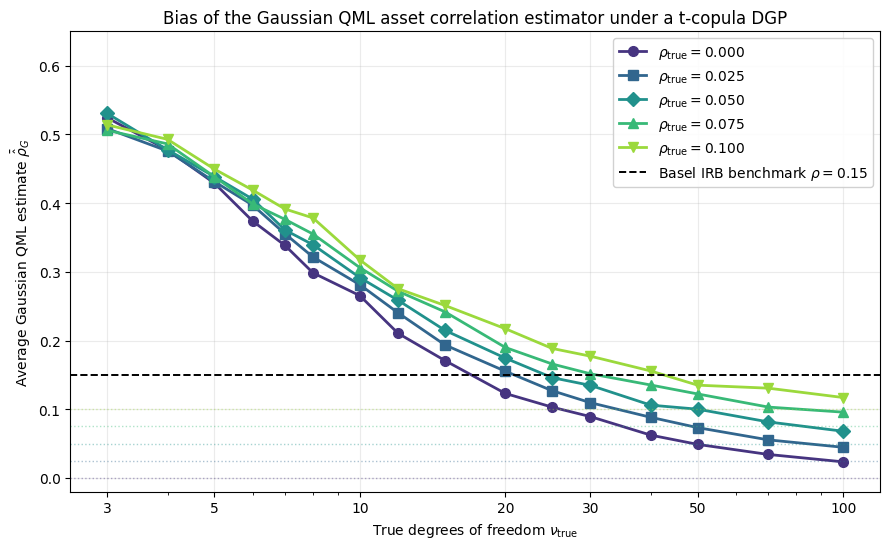

In [10]:
# -----------------------------------------------------------------------------
# Plot the bias function
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9.0, 5.6))

# Choose colours from a perceptually uniform colormap so the plot scales to
# any number of rho_true curves without manual colour bookkeeping.
n_curves = len(RHO_FINE_GRID)
cmap = plt.get_cmap("viridis")
colors = [cmap(0.15 + 0.7 * i / max(n_curves - 1, 1)) for i in range(n_curves)]
marker_pool = ["o", "s", "D", "^", "v", "P", "X", "*"]
markers = [marker_pool[i % len(marker_pool)] for i in range(n_curves)]

for i, rho_true in enumerate(RHO_FINE_GRID):
    sub = df_fine[df_fine["rho_true"] == rho_true].sort_values("nu_true")
    ax.plot(sub["nu_true"], sub["rho_hat_mean"],
            marker=markers[i], color=colors[i], linewidth=2.0,
            markersize=7, label=fr"$\rho_{{\mathrm{{true}}}} = {rho_true:.3f}$")
    ax.axhline(rho_true, color=colors[i], linestyle=":", linewidth=1.0, alpha=0.4)

ax.axhline(0.15, color="black", linestyle="--", linewidth=1.4,
           label=r"Basel IRB benchmark $\rho = 0.15$")
ax.set_xlabel(r"True degrees of freedom $\nu_{\mathrm{true}}$")
ax.set_ylabel(r"Average Gaussian QML estimate $\bar{\hat{\rho}}_G$")
ax.set_title("Bias of the Gaussian QML asset correlation estimator under a t-copula DGP")
ax.set_xscale("log")
ax.set_xticks([3, 5, 10, 20, 30, 50, 100])
ax.set_xticklabels(["3", "5", "10", "20", "30", "50", "100"])
ax.set_ylim(-0.02, 0.65)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.savefig("fig1_bias_function.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Loss distribution comparison

The bias plot shows that $\hat{\rho}_G$ is inflated, but it does not by
itself say whether the inflated estimator delivers an accurate forecast of
portfolio loss. This block compares three loss distributions on the same
panel, all evaluated at a marginal default probability of 1% and an asset
correlation of 5%:

1. **The true t-copula** with $\rho_{\text{true}} = 0.05$ and $\nu_{\text{true}} = 10$.
2. **The misspecified Gaussian copula** evaluated at the average
   $\hat{\rho}_G$ delivered by the QML estimator on data from regime (1).
3. **The naive Gaussian copula** evaluated at $\rho_{\text{true}} = 0.05$,
   which is what one would obtain by ignoring the t-copula structure
   altogether.

The point of the plot is the visual comparison between (1) and (2). They
should be close. The point of the plot is also the visual comparison
between (1) and (3). They should not be close. This is the H-R
self-correction at work.


In [11]:
# -----------------------------------------------------------------------------
# Parameters for the loss-distribution comparison
# -----------------------------------------------------------------------------

LOSS_RHO_TRUE = 0.05
LOSS_NU_TRUE = 10.0
LOSS_LAM = 0.01
LOSS_N = 1000
LOSS_M = 50000 if not SMOKE_TEST else 5000

# Look up the corresponding biased rho_hat from the fine grid.
match = df_fine[(np.isclose(df_fine["rho_true"], LOSS_RHO_TRUE))
                & (np.isclose(df_fine["nu_true"], LOSS_NU_TRUE))]
if len(match) == 0:
    out = run_replication_cell(LOSS_RHO_TRUE, LOSS_NU_TRUE, LOSS_LAM,
                               100, T_PERIODS, LOSS_N, 9999)
    LOSS_RHO_BIASED = out["rho_hat_mean"]
else:
    LOSS_RHO_BIASED = float(match["rho_hat_mean"].iloc[0])

print(f"True parameters:   rho = {LOSS_RHO_TRUE:.4f},  nu = {LOSS_NU_TRUE:.1f}")
print(f"Biased Gaussian:   rho_hat_G = {LOSS_RHO_BIASED:.4f}")
print(f"Naive Gaussian:    rho = rho_true = {LOSS_RHO_TRUE:.4f}")


True parameters:   rho = 0.0500,  nu = 10.0
Biased Gaussian:   rho_hat_G = 0.2916
Naive Gaussian:    rho = rho_true = 0.0500


In [12]:
# -----------------------------------------------------------------------------
# Simulate the three loss distributions
# -----------------------------------------------------------------------------

rng_loss = np.random.default_rng(424242)

# Regime (1): true t-copula
z1 = rng_loss.standard_normal(LOSS_M)
w1 = rng_loss.chisquare(df=LOSS_NU_TRUE, size=LOSS_M)
p1 = t_conditional_pd(z1, w1, LOSS_LAM, LOSS_RHO_TRUE, LOSS_NU_TRUE)
loss_true_t = rng_loss.binomial(LOSS_N, p1) / LOSS_N

# Regime (2): biased Gaussian
z2 = rng_loss.standard_normal(LOSS_M)
p2 = gaussian_conditional_pd(z2, LOSS_LAM, LOSS_RHO_BIASED)
loss_biased_gauss = rng_loss.binomial(LOSS_N, p2) / LOSS_N

# Regime (3): naive Gaussian
z3 = rng_loss.standard_normal(LOSS_M)
p3 = gaussian_conditional_pd(z3, LOSS_LAM, LOSS_RHO_TRUE)
loss_naive_gauss = rng_loss.binomial(LOSS_N, p3) / LOSS_N


def empirical_var(losses, alpha):
    """Empirical alpha-quantile of the loss vector."""
    return float(np.quantile(losses, alpha))


def empirical_es(losses, alpha):
    """Empirical Expected Shortfall: average loss above the alpha-quantile."""
    var = empirical_var(losses, alpha)
    tail = losses[losses >= var]
    return float(tail.mean()) if len(tail) > 0 else float(var)


summary = pd.DataFrame({
    "Regime": ["True t-copula", "Biased Gaussian", "Naive Gaussian"],
    "Mean": [loss_true_t.mean(), loss_biased_gauss.mean(), loss_naive_gauss.mean()],
    "VaR 99%": [empirical_var(loss_true_t, 0.99),
                empirical_var(loss_biased_gauss, 0.99),
                empirical_var(loss_naive_gauss, 0.99)],
    "VaR 99.9%": [empirical_var(loss_true_t, 0.999),
                  empirical_var(loss_biased_gauss, 0.999),
                  empirical_var(loss_naive_gauss, 0.999)],
    "ES 99%": [empirical_es(loss_true_t, 0.99),
               empirical_es(loss_biased_gauss, 0.99),
               empirical_es(loss_naive_gauss, 0.99)],
})
summary.round(5)


,Regime,Mean,VaR 99%,VaR 99.9%,ES 99%
0,True t-copula,0.00988,0.093,0.174,0.12935
1,Biased Gaussian,0.01002,0.102,0.215,0.15155
2,Naive Gaussian,0.01005,0.034,0.052,0.04071


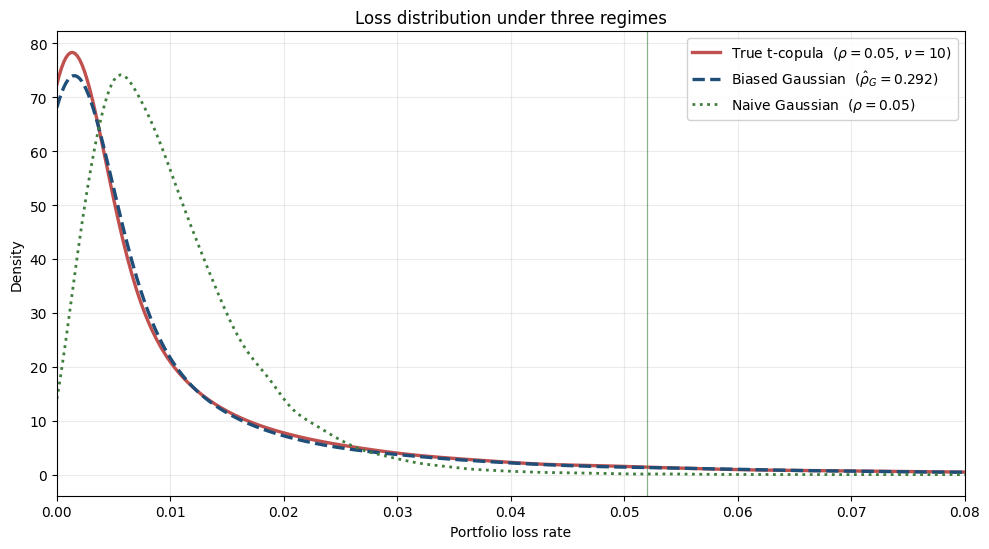

In [13]:
# -----------------------------------------------------------------------------
# Plot the three densities on the same axis
# -----------------------------------------------------------------------------

from scipy.stats import gaussian_kde

x_grid = np.linspace(0.0, 0.10, 500)
kde_true = gaussian_kde(loss_true_t, bw_method=0.15)
kde_bias = gaussian_kde(loss_biased_gauss, bw_method=0.15)
kde_naive = gaussian_kde(loss_naive_gauss, bw_method=0.15)

fig, ax = plt.subplots(figsize=(10.0, 5.6))

ax.plot(x_grid, kde_true(x_grid), color="#c0504d", linewidth=2.4,
        label=fr"True t-copula  ($\rho={LOSS_RHO_TRUE:.2f}$, $\nu={LOSS_NU_TRUE:.0f}$)")
ax.plot(x_grid, kde_bias(x_grid), color="#1f4e79", linewidth=2.4, linestyle="--",
        label=fr"Biased Gaussian  ($\hat{{\rho}}_G={LOSS_RHO_BIASED:.3f}$)")
ax.plot(x_grid, kde_naive(x_grid), color="#3e7d3e", linewidth=2.0, linestyle=":",
        label=fr"Naive Gaussian  ($\rho={LOSS_RHO_TRUE:.2f}$)")

# VaR 99.9% markers
for losses, color in [(loss_true_t, "#c0504d"),
                      (loss_biased_gauss, "#1f4e79"),
                      (loss_naive_gauss, "#3e7d3e")]:
    var999 = empirical_var(losses, 0.999)
    ax.axvline(var999, color=color, linewidth=0.9, alpha=0.6)

ax.set_xlabel("Portfolio loss rate")
ax.set_ylabel("Density")
ax.set_title("Loss distribution under three regimes")
ax.set_xlim(0.0, 0.08)
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig2_loss_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Consistency map: where do empirical estimates fall?

Suppose one observes an empirical Gaussian QML estimate $\hat{\rho}_G$
from a large mortgage panel. Under the H-R framework, this estimate is
compatible with a continuum of $(\rho_{\text{true}}, \nu_{\text{true}})$
combinations: a low $\hat{\rho}_G$ can come from a low $\rho_{\text{true}}$
with high $\nu_{\text{true}}$ (near-Gaussian world), or from a moderate
$\rho_{\text{true}}$ with very high $\nu_{\text{true}}$, but it cannot
easily come from a heavy-tailed world.

The contour plot below shows level sets of the average $\hat{\rho}_G$ over
the $(\rho_{\text{true}}, \nu_{\text{true}})$ plane. Reading it: any
level corresponds to a hypothetical empirical observation, and the contour
identifies the parameter combinations that would produce that observation
under the H-R mechanism. The plot is the natural input to a discussion of
which parameter region is empirically supported by data on US conforming
residential mortgages, a question that subsequent posts in the series take
up.


In [14]:
# -----------------------------------------------------------------------------
# Build the consistency surface
# -----------------------------------------------------------------------------

if SMOKE_TEST:
    RHO_SURF = np.array([0.0, 0.05, 0.10])
    NU_SURF = np.array([5.0, 10.0, 30.0])
    M_SURF = 30
else:
    RHO_SURF = np.array([0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.15])
    NU_SURF = np.array([3.0, 5.0, 7.0, 10.0, 13.0, 17.0, 22.0, 30.0,
                        40.0, 60.0, 100.0])
    M_SURF = 300

LAMBDA_SURF = 0.01

surface = np.empty((len(RHO_SURF), len(NU_SURF)))
seed_counter_surf = 30000
for i, rho_true in enumerate(RHO_SURF):
    for j, nu_true in enumerate(NU_SURF):
        out = run_replication_cell(rho_true, nu_true, LAMBDA_SURF, M_SURF,
                                   T_PERIODS, N_OBLIGORS, seed_counter_surf)
        surface[i, j] = out["rho_hat_mean"]
        seed_counter_surf += 1
    print(f"  rho_true = {rho_true:.3f} done")

print(f"Run finished: {datetime.datetime.now().isoformat(timespec='seconds')}")


  rho_true = 0.000 done
  rho_true = 0.020 done
  rho_true = 0.040 done
  rho_true = 0.060 done
  rho_true = 0.080 done
  rho_true = 0.100 done
  rho_true = 0.120 done
  rho_true = 0.150 done
Run finished: 2026-05-22T00:56:07


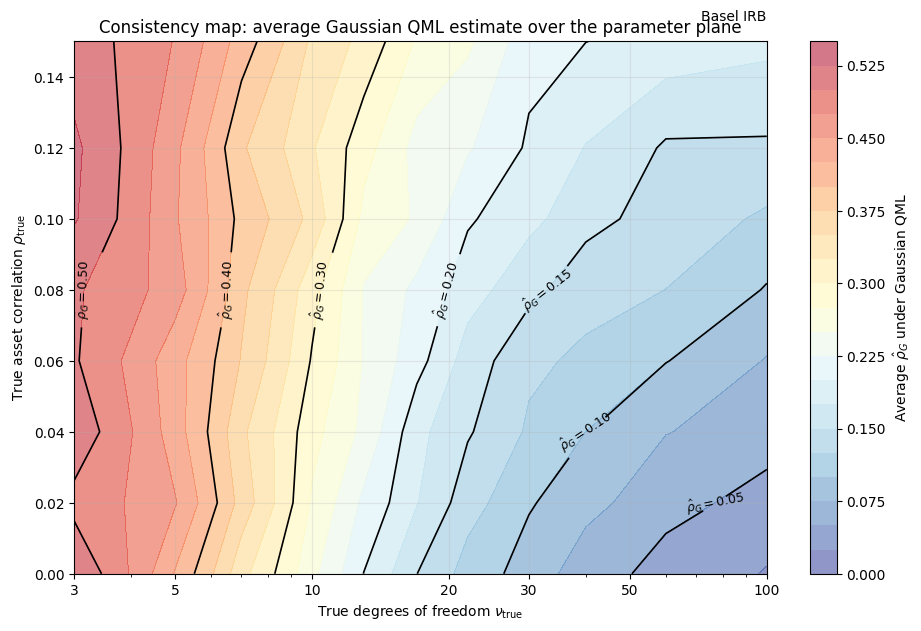

In [15]:
# -----------------------------------------------------------------------------
# Contour plot of the bias surface
# -----------------------------------------------------------------------------

NU_grid, RHO_grid = np.meshgrid(NU_SURF, RHO_SURF)

fig, ax = plt.subplots(figsize=(9.6, 6.4))

contour_levels = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
cs = ax.contour(NU_grid, RHO_grid, surface, levels=contour_levels,
                colors="black", linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=9, fmt=r"$\hat{\rho}_G = %.2f$")

cf = ax.contourf(NU_grid, RHO_grid, surface, levels=20, cmap="RdYlBu_r", alpha=0.55)
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"Average $\hat{\rho}_G$ under Gaussian QML")

ax.axhline(0.15, color="black", linestyle="--", linewidth=1.2)
ax.text(NU_SURF[-1], 0.155, "Basel IRB", ha="right", va="bottom", fontsize=10)

ax.set_xlabel(r"True degrees of freedom $\nu_{\mathrm{true}}$")
ax.set_ylabel(r"True asset correlation $\rho_{\mathrm{true}}$")
ax.set_title("Consistency map: average Gaussian QML estimate over the parameter plane")
ax.set_xscale("log")
ax.set_xticks([3, 5, 10, 20, 30, 50, 100])
ax.set_xticklabels(["3", "5", "10", "20", "30", "50", "100"])
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig3_consistency_map.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Discussion

Three observations follow from the figures above and shape the reading of
empirical results in subsequent posts.

**On the survival of the Basel IRB framework.** The Gaussian copula has
zero tail dependence, a property that should disqualify it as a model of
joint default behaviour in periods of systemic stress. The simulations in
Section 5 explain why the framework nonetheless produces capital figures
that are not obviously dangerous. Calibration to default data inflates
$\hat{\rho}_G$ in a way that compensates for the missing tail dependence.
The biased Gaussian forecast and the true t-copula forecast track each
other across the body of the loss distribution and through moderate
quantiles. The mechanism is mechanical, not designed.

**Where the compensation breaks.** The summary table shows that the
biased Gaussian and the true t-copula deliver similar 99% VaR, but the
agreement deteriorates at 99.9%, and Expected Shortfall amplifies the gap
further. This is the natural counterpart of the zero-tail-dependence
property of the Gaussian copula: no amount of upward bias in $\hat{\rho}_G$
can reproduce the asymptotic linkage that a t-copula imposes between
extreme co-movements. For risk measures that probe further into the tail,
the misspecification reasserts itself.

**On reading empirical estimates.** The consistency map of Section 6
makes clear that an empirical $\hat{\rho}_G$ does not, on its own, identify
the underlying $(\rho_{\text{true}}, \nu_{\text{true}})$ pair. A given
contour level is consistent with a low correlation under near-Gaussian
dependence and with a higher correlation under heavy-tailed dependence.
Discriminating between these regimes requires additional information:
direct estimation of $\nu$ from the same panel, dynamic evidence on
correlation through the cycle, and decomposition of pooled estimates into
within-cohort and between-cohort components. Subsequent posts in this
series take up each of these in turn.

A further point that deserves emphasis: the H-R simulation environment
holds the panel structure fixed at $T = 10$ and $N = 1000$. Real
portfolios depart from this in both directions. Long histories with deep
recessions sample the lower tail more aggressively than the simulation
implies, while highly granular portfolios reduce the binomial sampling
variance and let small differences between $p_G$ and $p_t$ surface as
identifiable bias signal. Whether the H-R compensation operates with the
strength they document on a given empirical panel is itself an empirical
question, and it is one that the data series for the US conforming
residential mortgage portfolio offers a clean way to test.


## References

- Basel Committee on Banking Supervision (2005). *An Explanatory Note on
  the Basel II IRB Risk Weight Functions*. Bank for International
  Settlements.
- Frey, R., McNeil, A. J., and Nyfeler, M. (2001). Copulas and credit
  models. *Risk*, 14, 111–114.
- Hamerle, A., and Rösch, D. (2005). Misspecified copulas in credit risk
  models: How good is Gaussian? *Journal of Risk*, 8(1), 41–58.
- Li, D. X. (2000). On default correlation: A copula function approach.
  *Journal of Fixed Income*, 9, 43–54.
- Löffler, G., and Posch, P. (2011). *Credit Risk Modeling Using Excel
  and VBA*, second edition. Wiley.
- Rösch, D., and Scheule, H. (2022). *Deep Credit Risk*, second edition.
  Independently published.
- Vasicek, O. (2002). The distribution of loan portfolio value. *Risk*,
  15(12), 160–162.
